In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("sampledata.csv")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [5]:
df.shape
df.columns
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

The data set has been inspected to understand it's dimensions,column names,data types, summary statistics and the presence of missing values hence identifying any issues that need to be addressed before using the data set.

In [23]:
df.corr(numeric_only=True)

,Row ID,Sales,Quantity,Discount,Profit,Order Year,Profit Margin (%)
Row ID,1.000000,-0.008958,0.000502,-0.001474,0.003022,0.960606,0.001198
Sales,-0.008958,1.000000,0.198457,-0.027756,0.481460,-0.009051,0.002707
Quantity,0.000502,0.198457,1.000000,0.007475,0.066145,-0.006136,-0.003830
Discount,-0.001474,-0.027756,0.007475,1.000000,-0.218882,0.000474,-0.864821
Profit,0.003022,0.481460,0.066145,-0.218882,1.000000,0.004627,0.223224
Order Year,0.960606,-0.009051,-0.006136,0.000474,0.004627,1.000000,-0.001898
Profit Margin (%),0.001198,0.002707,-0.003830,-0.864821,0.223224,-0.001898,1.000000


The correlation matrix is created so as to examine the relationships between numerical variables in the data set.

In [6]:
df.duplicated().sum()

0

In [7]:

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  datetime64[ns]
 4   Ship Mode       10194 non-null  object        
 5   Customer ID     10194 non-null  object        
 6   Customer Name   10194 non-null  object        
 7   Segment         10194 non-null  object        
 8   Country/Region  10194 non-null  object        
 9   City            10194 non-null  object        
 10  State/Province  10194 non-null  object        
 11  Postal Code     10194 non-null  object        
 12  Region          10194 non-null  object        
 13  Product ID      10194 non-null  object        
 14  Category        10194 non-null  object        
 15  Su

The Order Date and Ship Date columns have been converted to the date time format. This is to enable date-based analysis and to ensure consistency in the data set.

In [8]:
df[["Sales", "Quantity", "Discount", "Profit"]].describe()

,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000
mean,228.225854,3.791838,0.155385,28.673417
std,619.906839,2.228317,0.206249,232.465115
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.220000,2.000000,0.000000,1.760800
50%,53.910000,3.000000,0.200000,8.690000
75%,209.500000,5.000000,0.200000,29.297925
max,22638.480000,14.000000,0.800000,8399.976000


The statistics have been worked out to understand the distribution, and to help in the identification of potential outliers.

In [9]:
(df == "").sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

This was done to ensure that no blank entries exist in the data set.

In [11]:
sales_by_category = df.groupby("Category")["Sales"].sum()
sales_by_category

Category
Furniture          754747.7613
Office Supplies    731893.3140
Technology         839893.2790
Name: Sales, dtype: float64

In [12]:
profit_by_region = df.groupby("Region")["Profit"].sum()
profit_by_region

Region
Central     39865.3070
East        94883.2603
South       46749.4303
West       110798.8170
Name: Profit, dtype: float64

In [13]:
average_sales_segment = df.groupby("Segment")["Sales"].mean()
average_sales_segment

Segment
Consumer       221.673885
Corporate      231.652471
Home Office    241.397933
Name: Sales, dtype: float64

In [14]:
orders_shipmode = df.groupby("Ship Mode").size()
orders_shipmode

Ship Mode
First Class       1548
Same Day           547
Second Class      1979
Standard Class    6120
dtype: int64

In [15]:
top_sales = df.sort_values(by="Sales", ascending=False)
top_sales.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
226,227,US-2023-145317,2023-03-18,2023-03-23,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,...,32216,South,TEC-MA-10002412,Technology,Machines,Cisco TelePresence System EX90 Videoconferenci...,22638.480,6,0.5,-1811.0784
5894,5895,US-2025-118689,2025-10-02,2025-10-09,Standard Class,TC-20980,Tamara Chand,Corporate,United States,Lafayette,...,47905,Central,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,17499.950,5,0.0,8399.9760
7255,7256,US-2026-140151,2026-03-23,2026-03-25,First Class,RB-19360,Raymond Buch,Consumer,United States,Seattle,...,98115,West,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,13999.960,4,0.0,6719.9808
9171,9172,US-2026-127180,2026-10-22,2026-10-24,First Class,TA-21385,Tom Ashbrook,Home Office,United States,New York City,...,10024,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,11199.968,4,0.2,3919.9888
9517,9518,US-2026-166709,2026-11-17,2026-11-22,Standard Class,HL-15040,Hunter Lopez,Consumer,United States,Newark,...,19711,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,10499.970,3,0.0,5039.9856
6674,6675,US-2025-117121,2025-12-17,2025-12-21,Standard Class,AB-10105,Adrian Barton,Consumer,United States,Detroit,...,48205,Central,OFF-BI-10000545,Office Supplies,Binders,GBC Ibimaster 500 Manual ProClick Binding System,9892.740,13,0.0,4946.3700
1203,1204,US-2023-116904,2023-09-23,2023-09-28,Standard Class,SC-20095,Sanjit Chand,Consumer,United States,Minneapolis,...,55407,Central,OFF-BI-10001120,Office Supplies,Binders,Ibico EPK-21 Electric Binding System,9449.950,5,0.0,4630.4755
4624,4625,US-2025-107440,2025-04-16,2025-04-20,Standard Class,BS-11365,Bill Shonely,Corporate,United States,Lakewood,...,8701,East,TEC-MA-10001047,Technology,Machines,"3D Systems Cube Printer, 2nd Generation, Magenta",9099.930,7,0.0,2365.9818
4282,4283,US-2025-158841,2025-02-02,2025-02-04,Second Class,SE-20110,Sanjit Engle,Consumer,United States,Arlington,...,22204,South,TEC-MA-10001127,Technology,Machines,HP Designjet T520 Inkjet Large Format Printer ...,8749.950,5,0.0,2799.9840
4845,4846,US-2025-143714,2025-05-23,2025-05-27,Standard Class,CC-12370,Christopher Conant,Consumer,United States,Philadelphia,...,19120,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,8399.976,4,0.4,1119.9968


The data has been grouped and reorganized. For the first block of code the data set is grouped by product category, and the total sales for each category are calculated to identify the highest-performing categories. Then it's grouped by region to calculate the total profit generated in each region. Next the average sales value is calculated for each customer segment to compare purchasing patterns and number of orders handled through each shipping method is calculated. Lastly the data set is sorted in descending order of sales to identify the largest transactions.

In [16]:
df["Order Year"] = df["Order Date"].dt.year
df[["Order Date", "Order Year"]].head()

,Order Date,Order Year
0,2023-01-03,2023
1,2023-01-04,2023
2,2023-01-04,2023
3,2023-01-04,2023
4,2023-01-05,2023


In [17]:
df["Order Month"] = df["Order Date"].dt.month_name()
df[["Order Date", "Order Month"]].head()

,Order Date,Order Month
0,2023-01-03,January
1,2023-01-04,January
2,2023-01-04,January
3,2023-01-04,January
4,2023-01-05,January


In [18]:
df["Profit Margin (%)"] = (df["Profit"] / df["Sales"]) * 100
df[["Sales", "Profit", "Profit Margin (%)"]].head()

,Sales,Profit,Profit Margin (%)
0,16.448,5.5512,33.75
1,3.540,-5.4870,-155.00
2,11.784,4.2717,36.25
3,272.736,-64.7748,-23.75
4,19.536,4.8840,25.00


In [19]:
def sales_category(sales):
    if sales < 100:
        return "Low"
    elif sales < 500:
        return "Medium"
    else:
        return "High"

df["Sales Category"] = df["Sales"].apply(sales_category)

df[["Sales", "Sales Category"]].head()

,Sales,Sales Category
0,16.448,Low
1,3.540,Low
2,11.784,Low
3,272.736,Medium
4,19.536,Low


In [20]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Profit Margin (%),Sales Category
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,2023,January,33.75,Low
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,2023,January,-155.00,Low
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Labels,Avery 508,11.784,3,0.2,4.2717,2023,January,36.25,Low
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,2023,January,-23.75,Medium
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,2023,January,25.00,Low


In [21]:
df.to_csv("sampledata_processed.csv", index=False)

A new column containing the year of each order is created from the Order Date column.
The month name is extracted from the Order Date column to make monthly analysis easier.
Then a new column called Profit Margin is created by dividing Profit by Sales and multiplying by 100. This shows the percentage profit earned on each sale.
Sales values are grouped into Low, Medium, and High categories to simplify analysis.The first five rows of the newly created features are displayed to confirm that they have been added correctly.

### Graph to show Total Sales by Category

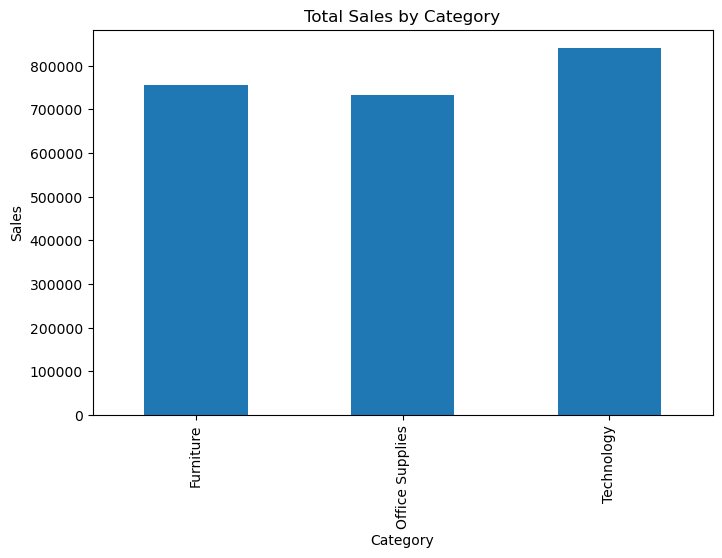

In [24]:
sales_by_category.plot(kind="bar", figsize=(8,5))
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

### Graph to show Total Profit by Region

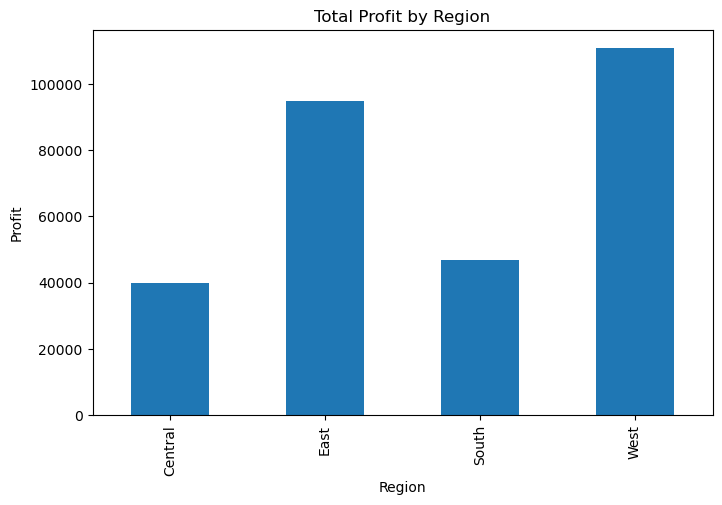

In [25]:
profit_by_region.plot(kind="bar", figsize=(8,5))
plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()

### Correlation Heatmap

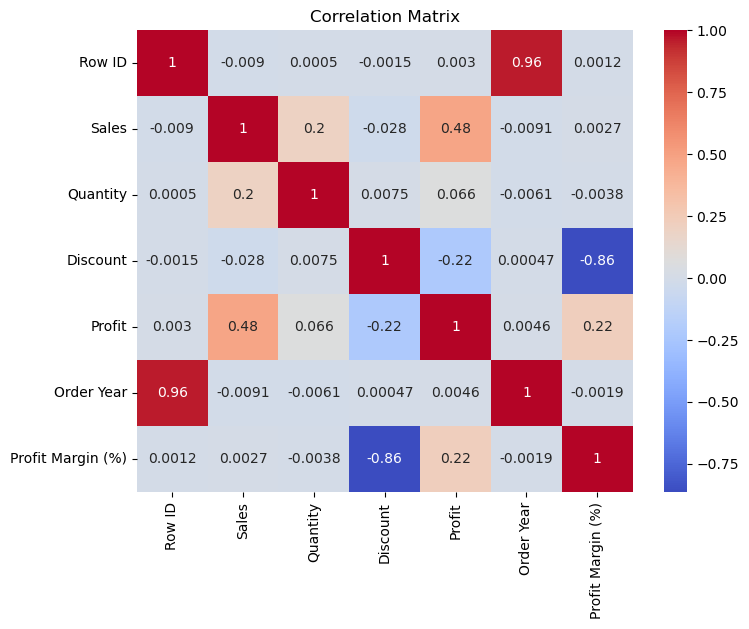

In [26]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

The heat map is used to visually show that the greater the correlation, the greater the interactivity between the two variables.

### Scatter Plot: Sales vs Profit

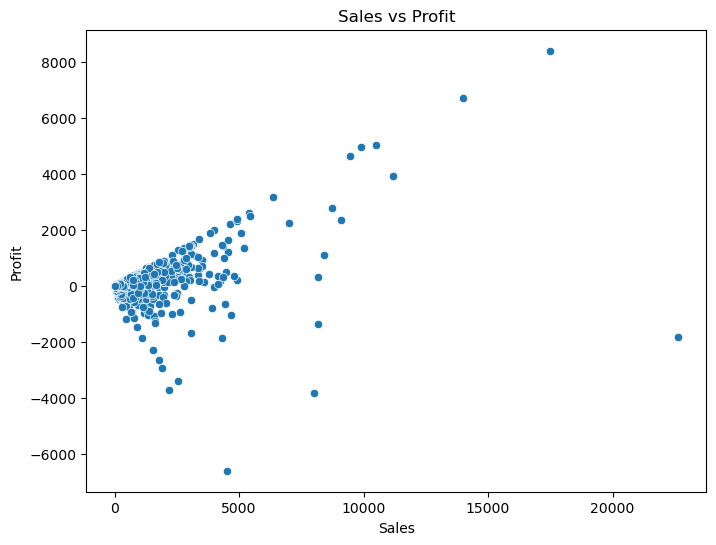

In [27]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Sales", y="Profit")
plt.title("Sales vs Profit")
plt.show()

The scatter plot displays the relationship between sales and profit. Most transactions involve relatively low sales values, while a few high-value transactions appear as outliers. It also shows that higher sales do not always correspond to higher profit, indicating that factors such as discounts or product costs may affect profitability.